In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
df = pd.read_csv("exchange_rate.csv")

df['date'] = pd.to_datetime(df['date'], dayfirst=True)

df.set_index('date', inplace=True)

print(df.head())

            Ex_rate
date               
1990-01-01   0.7855
1990-01-02   0.7818
1990-01-03   0.7867
1990-01-04   0.7860
1990-01-05   0.7849


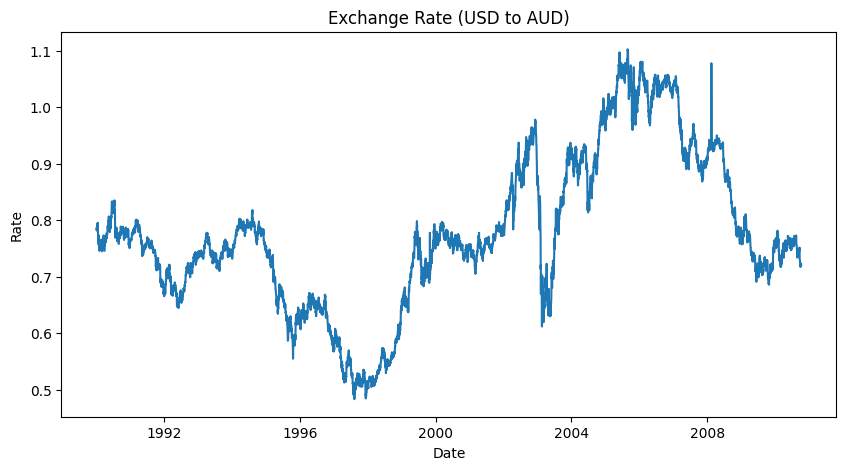

In [3]:
plt.figure(figsize=(10,5))
plt.plot(df.iloc[:,0])
plt.title("Exchange Rate (USD to AUD)")
plt.xlabel("Date")
plt.ylabel("Rate")
plt.show()



In [4]:
# Handle missing values
df.fillna(method='ffill', inplace=True)

print("Missing values:\n", df.isnull().sum())

Missing values:
 Ex_rate    0
dtype: int64


In [5]:
train_size = int(len(df) * 0.8)

train = df.iloc[:train_size]
test = df.iloc[train_size:]

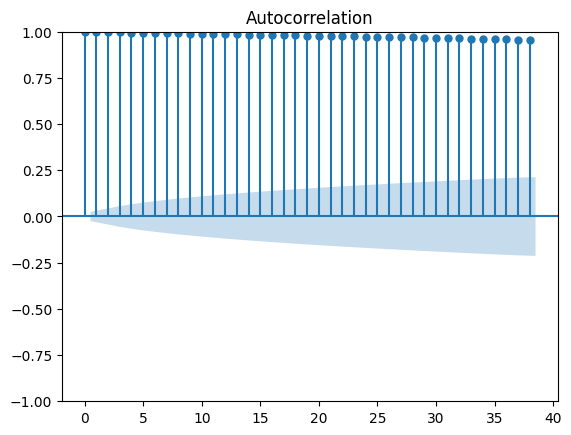

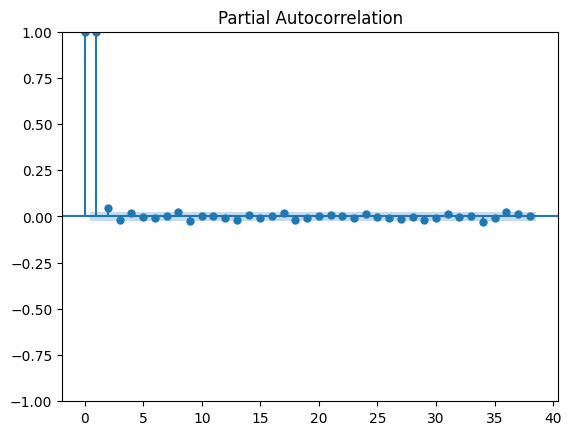

In [6]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(train.iloc[:,0])
plot_pacf(train.iloc[:,0])
plt.show()

In [7]:
model_arima = ARIMA(train, order=(1,1,1))
model_arima_fit = model_arima.fit()

print(model_arima_fit.summary())

C:\Users\aftab\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\aftab\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\aftab\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 6070
Model:                 ARIMA(1, 1, 1)   Log Likelihood               22719.046
Date:                Mon, 23 Mar 2026   AIC                         -45432.092
Time:                        07:56:51   BIC                         -45411.959
Sample:                    01-01-1990   HQIC                        -45425.104
                         - 08-14-2006                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5972      0.062     -9.648      0.000      -0.719      -0.476
ma.L1          0.5398      0.064      8.430      0.000       0.414       0.665
sigma2      3.281e-05   1.95e-07    168.198      0.0

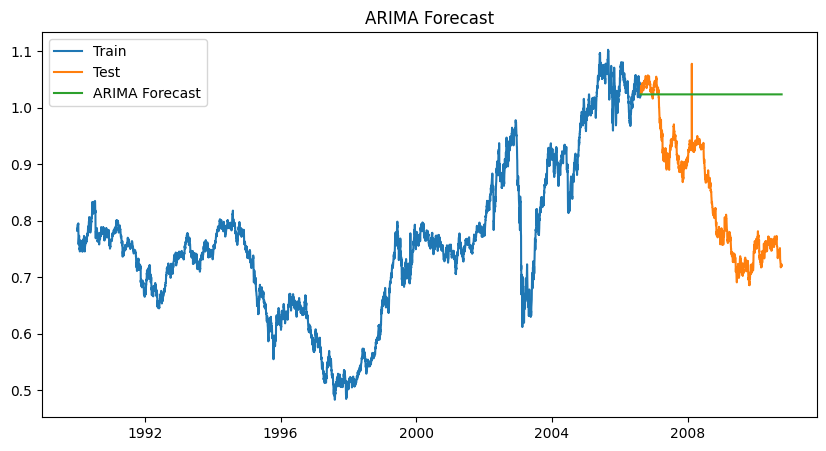

In [8]:
forecast_arima = model_arima_fit.forecast(steps=len(test))

plt.figure(figsize=(10,5))
plt.plot(train, label='Train')
plt.plot(test, label='Test')
plt.plot(test.index, forecast_arima, label='ARIMA Forecast')
plt.legend()
plt.title("ARIMA Forecast")
plt.show()

In [9]:
model_es = ExponentialSmoothing(train, trend='add', seasonal=None)
model_es_fit = model_es.fit()

C:\Users\aftab\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


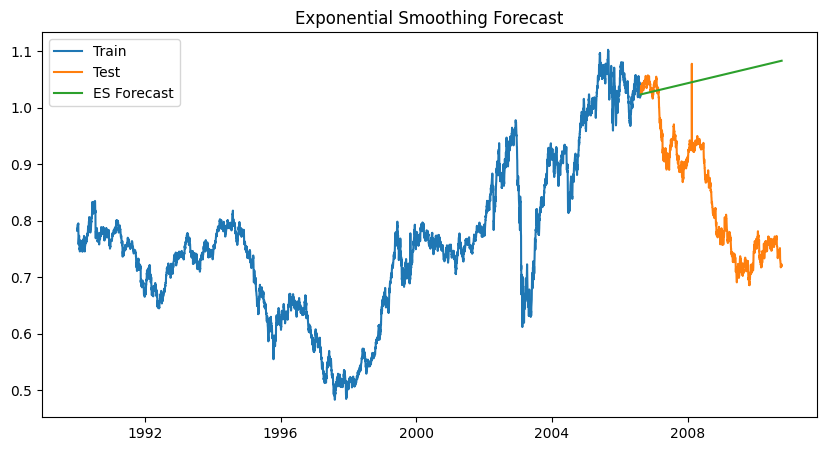

In [10]:
forecast_es = model_es_fit.forecast(len(test))

plt.figure(figsize=(10,5))
plt.plot(train, label='Train')
plt.plot(test, label='Test')
plt.plot(test.index, forecast_es, label='ES Forecast')
plt.legend()
plt.title("Exponential Smoothing Forecast")
plt.show()

In [11]:
def evaluate(actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    
    return mae, rmse, mape


In [17]:
# ARIMA
mae_a, rmse_a, mape_a = evaluate(test, forecast_arima)